In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

print("✅ Все библиотеки импортированы")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")
print(f"Python: {sys.version}")

✅ Все библиотеки импортированы
TensorFlow: 2.20.0
Keras: 3.13.2
Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]


In [12]:
import os

# Переходим в папку проекта
os.chdir(r'D:\Projects\image-classification')
print(f"✅ Теперь мы в: {os.getcwd()}")
print(f"✅ Содержимое проекта: {os.listdir()}")

✅ Теперь мы в: D:\Projects\image-classification
✅ Содержимое проекта: ['app', 'data', 'models', 'notebooks']


In [3]:
import os

# Твой точный путь к проекту
project_path = r'D:\Projects\image-classification'
os.chdir(project_path)

print(f"✅ Рабочая папка: {os.getcwd()}")
print(f"✅ Содержит data: {'data' in os.listdir()}")

✅ Рабочая папка: D:\Projects\image-classification
✅ Содержит data: True


In [7]:
import os
import tensorflow as tf
import cv2
import numpy as np

def clean_dataset(folder_path):
    """Удаляет все потенциально проблемные изображения"""
    removed = 0
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                file_path = os.path.join(root, file)
                try:
                    # Пробуем прочитать через TensorFlow
                    img_raw = tf.io.read_file(file_path)
                    img = tf.image.decode_image(img_raw, channels=3)
                    
                    # Проверяем размер
                    if img.shape[0] == 0 or img.shape[1] == 0:
                        os.remove(file_path)
                        removed += 1
                        print(f"❌ Удалён (нулевой размер): {file_path}")
                        
                except Exception as e:
                    # Если TensorFlow не может прочитать - удаляем
                    os.remove(file_path)
                    removed += 1
                    print(f"❌ Удалён (ошибка): {file_path}")
    
    return removed

print("Очищаем train...")
removed_train = clean_dataset('data/train')

print("\nОчищаем validation...")
removed_val = clean_dataset('data/validation')

print(f"\n✅ Всего удалено файлов: {removed_train + removed_val}")

Очищаем train...
❌ Удалён (ошибка): data/train\cats\10404.jpg
❌ Удалён (ошибка): data/train\cats\4351.jpg
❌ Удалён (ошибка): data/train\cats\666.jpg
❌ Удалён (ошибка): data/train\dogs\11702.jpg
❌ Удалён (ошибка): data/train\dogs\11912.jpg
❌ Удалён (ошибка): data/train\dogs\2317.jpg
❌ Удалён (ошибка): data/train\dogs\2494.jpg
❌ Удалён (ошибка): data/train\dogs\9500.jpg

Очищаем validation...
❌ Удалён (ошибка): data/validation\dogs\11233.jpg

✅ Всего удалено файлов: 9


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Параметры
IMG_SIZE = 150
BATCH_SIZE = 32

# Загружаем обучающие данные
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

# Загружаем валидационные данные
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/validation',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

# Сохраняем имена классов
class_names = train_ds.class_names
print(f"✅ Классы: {class_names}")

# Нормализация (0-255 → 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Оптимизация производительности
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"✅ Данные готовы")
print(f"  - Обучающих батчей: {len(train_ds)}")
print(f"  - Валидационных батчей: {len(val_ds)}")

Found 19998 files belonging to 2 classes.
Found 5002 files belonging to 2 classes.
✅ Классы: ['cats', 'dogs']
✅ Данные готовы
  - Обучающих батчей: 625
  - Валидационных батчей: 157


In [1]:
import os
os.chdir(r'D:\Projects\image-classification')
print("Текущая папка:", os.getcwd())

Текущая папка: D:\Projects\image-classification


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 150
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/validation',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_ds.class_names
print(f"✅ Классы: {class_names}")

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"✅ Данные готовы")
print(f"  - Обучающих батчей: {len(train_ds)}")
print(f"  - Валидационных батчей: {len(val_ds)}")

Found 19990 files belonging to 2 classes.
Found 5001 files belonging to 2 classes.
✅ Классы: ['cats', 'dogs']
✅ Данные готовы
  - Обучающих батчей: 625
  - Валидационных батчей: 157


In [3]:
# Создаём модель (если ещё не создана)
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Коллбэки
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'models/best_cnn_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

# ОБУЧЕНИЕ
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

print("✅ Обучение завершено!")

C:\Users\Китя\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4522s 7s/step - accuracy: 0.6396 - loss: 0.6345 - val_accuracy: 0.7295 - val_loss: 0.5366
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3129s 5s/step - accuracy: 0.7532 - loss: 0.5067 - val_accuracy: 0.7984 - val_loss: 0.4341
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3051s 5s/step - accuracy: 0.8182 - loss: 0.4057 - val_accuracy: 0.8248 - val_loss: 0.3885
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3088s 5s/step - accuracy: 0.8530 - loss: 0.3393 - val_accuracy: 0.8434 - val_loss: 0.3584
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3180s 5s/step - accuracy: 0.8803 - loss: 0.2808 - val_accuracy: 0.8544 - val_loss: 0.3554
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3070s 5s/step - accuracy: 0.9075 - loss: 0.2227 - val_accuracy: 0.8562 - val_loss: 0.3875
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3067s 5s/step - accuracy: 0.9231 - loss: 0.1901 - val_accuracy: 0.8572 - val_loss: 0.3821
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3073s 5s/step - accuracy: 0.9417 - loss: 0.1443 - 

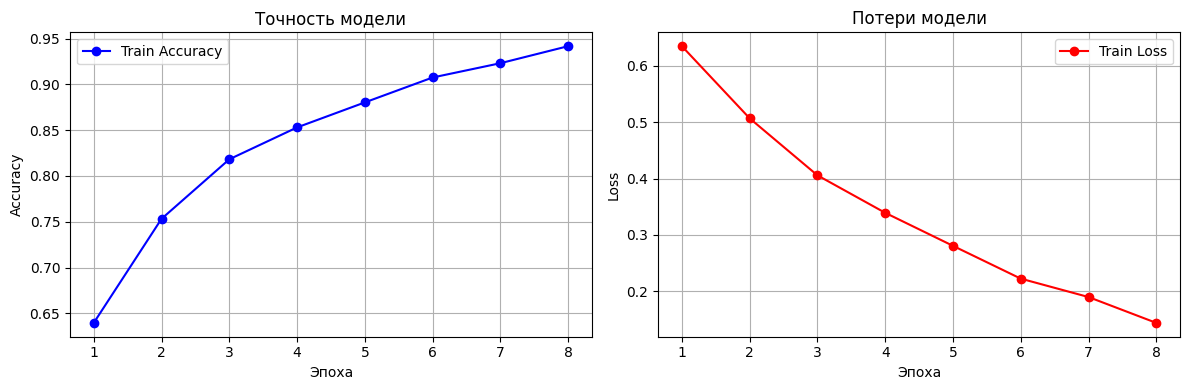

In [4]:
import matplotlib.pyplot as plt

# Данные из твоего обучения
accuracy = [0.6396, 0.7532, 0.8182, 0.8530, 0.8803, 0.9075, 0.9231, 0.9417]
loss = [0.6345, 0.5067, 0.4057, 0.3393, 0.2808, 0.2227, 0.1901, 0.1443]
epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, 'b-o', label='Train Accuracy')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r-o', label='Train Loss')
plt.title('Потери модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
# Сохраняем в современном формате .keras
model.save('models/cats_dogs_cnn_final.keras')
print("✅ Модель сохранена в новом формате!")



✅ Модель сохранена в новом формате!
